# Lab 04 — Skin Lesion Boundary Detection Using Canny Edge Detection

**Problem statement:** develop a simple computer vision system that detects the boundary of a
skin lesion from a skin image using image filtering and Canny edge detection, and determine
how effectively edge detection separates the lesion from the surrounding skin.

**Consistency with Labs 1-3:**
- Same dataset, downloaded once via `kagglehub` (no manual download), cached locally.
- Same 5 selected classes as Labs 1-3 — used here to naturally supply **5 representative
  images** (one per class), matching the lab's "Image 1" … "Image 5" results table.
- Same coding style: plain OpenCV/NumPy, one representative image set loaded once and reused
  across every step, nothing re-downloaded per cell.

**What's different from Labs 1-3:** there's no model training here at all — this lab is pure
classical image processing (filtering, edge detection, contour-based measurement), so it runs
instantly on CPU.


## 1. Setup

In [1]:
!pip install -q kagglehub opencv-python-headless


In [2]:
import os
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2. Dataset access (downloaded once, reused everywhere below)

Same dataset and 5 selected classes as Labs 1-3. `kagglehub` caches the download locally, so re-running this cell on a later session is instant.

In [3]:
import kagglehub

# Downloaded once; cached by kagglehub afterwards.
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
BASE_DIR = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
assert os.path.isdir(TRAIN_DIR), "Adjust TRAIN_DIR to match the printed structure"

SELECTED_CLASSES = [
    "actinic keratosis",
    "basal cell carcinoma",
    "melanoma",
    "nevus",
    "pigmented benign keratosis",
]
missing = [c for c in SELECTED_CLASSES if c not in os.listdir(TRAIN_DIR)]
assert not missing, f"Missing class folders: {missing}"
print("Classes:", SELECTED_CLASSES)


100%|██████████| 786M/786M [00:06<00:00, 118MB/s]

Extracting files...


Classes: ['actinic keratosis', 'basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis']


In [4]:
IMG_SIZE = 350  # a bit larger than the 224 used for CNN training, for clearer boundary visuals

def load_rgb(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize((size, size))
    return np.array(img)


def load_representative_images(classes, n_per_class=1, seed=SEED):
    # Loads n_per_class images per class, once, as (label, RGB uint8 image) pairs.
    rng = random.Random(seed)
    images = []
    for cls in classes:
        cls_dir = os.path.join(TRAIN_DIR, cls)
        files = sorted(os.listdir(cls_dir))
        chosen = rng.sample(files, min(n_per_class, len(files)))
        for fname in chosen:
            images.append((cls, load_rgb(os.path.join(cls_dir, fname))))
    return images


# Loaded once, reused by every task below -- 5 images (one per class), matching the
# lab's "Image 1" .. "Image 5" results table.
sample_images = load_representative_images(SELECTED_CLASSES, n_per_class=1)
IMAGE_LABELS = [f"Image {i+1}" for i in range(len(sample_images))]
print(f"Loaded {len(sample_images)} representative images (one per class).")
for label, (cls, _) in zip(IMAGE_LABELS, sample_images):
    print(f"  {label}: {cls}")


Loaded 5 representative images (one per class).
  Image 1: actinic keratosis
  Image 2: basal cell carcinoma
  Image 3: melanoma
  Image 4: nevus
  Image 5: pigmented benign keratosis


## 3. Task 1 — Load the Image

Displays the original image for all 5 selected images.

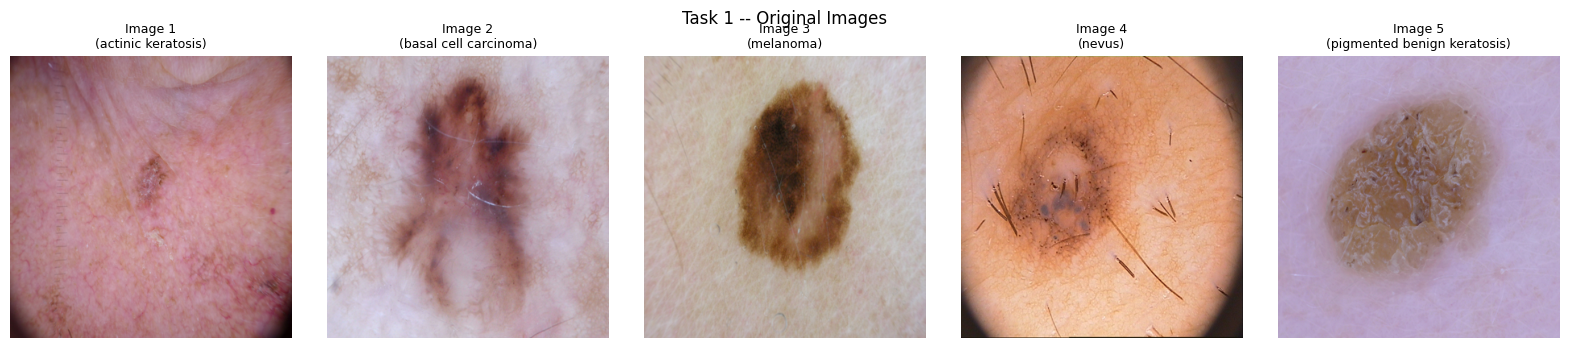

In [5]:
fig, axes = plt.subplots(1, len(sample_images), figsize=(3.2 * len(sample_images), 3.5))
for ax, label, (cls, img) in zip(axes, IMAGE_LABELS, sample_images):
    ax.imshow(img)
    ax.set_title(f"{label}\n({cls})", fontsize=9)
    ax.axis("off")
plt.suptitle("Task 1 -- Original Images")
plt.tight_layout()
plt.show()


## 4. Task 2 — Preprocess the Image

Grayscale conversion followed by a Gaussian filter to reduce noise, as required.

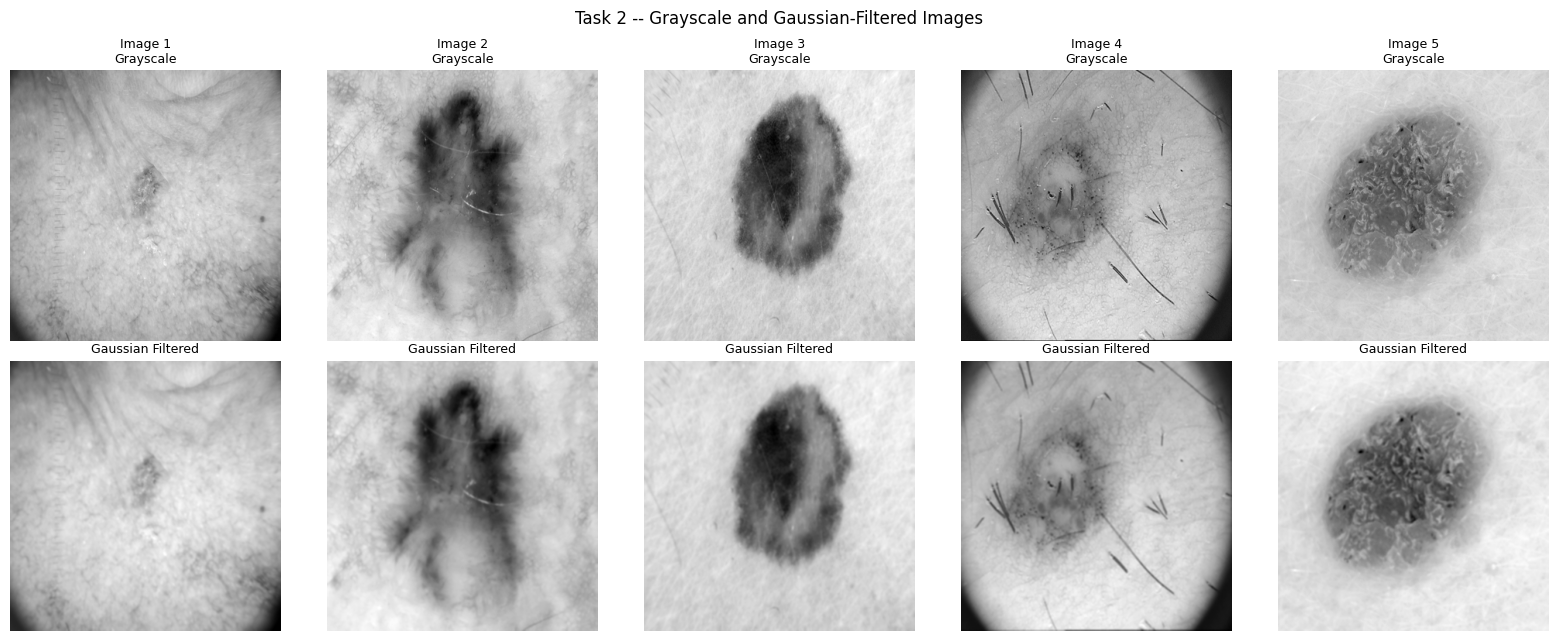

In [6]:
def to_grayscale(img_rgb):
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


def gaussian_filter(gray_img, kernel_size=5, sigma=0):
    return cv2.GaussianBlur(gray_img, (kernel_size, kernel_size), sigmaX=sigma)


fig, axes = plt.subplots(2, len(sample_images), figsize=(3.2 * len(sample_images), 6.5))
for col, (label, (cls, img)) in enumerate(zip(IMAGE_LABELS, sample_images)):
    gray = to_grayscale(img)
    blurred = gaussian_filter(gray)

    axes[0, col].imshow(gray, cmap="gray")
    axes[0, col].set_title(f"{label}\nGrayscale", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(blurred, cmap="gray")
    axes[1, col].set_title("Gaussian Filtered", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Task 2 -- Grayscale and Gaussian-Filtered Images")
plt.tight_layout()
plt.show()


## 5. Task 3 — Apply Canny Edge Detection (three threshold settings)

Threshold pairs as specified: 50-100, 100-200, 150-250, all on the Gaussian-filtered grayscale image from Task 2.

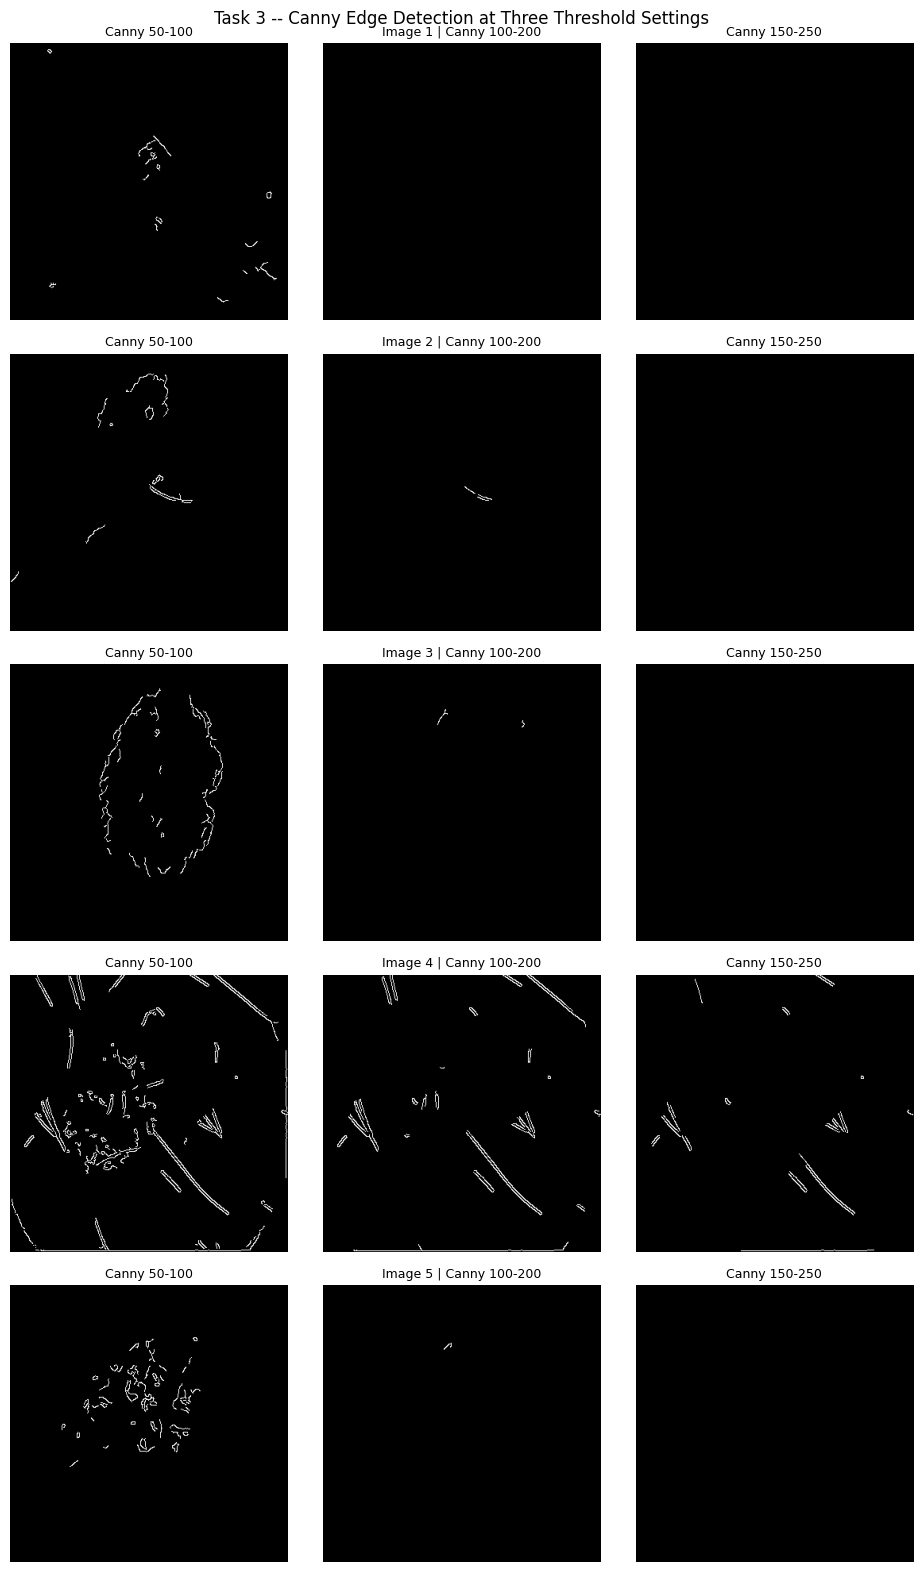

In [7]:
CANNY_THRESHOLDS = [
    ("50-100", 50, 100),
    ("100-200", 100, 200),
    ("150-250", 150, 250),
]


def apply_canny(gray_img, low, high):
    return cv2.Canny(gray_img, threshold1=low, threshold2=high)


fig, axes = plt.subplots(len(sample_images), len(CANNY_THRESHOLDS),
                          figsize=(3.2 * len(CANNY_THRESHOLDS), 3.2 * len(sample_images)))
for row, (label, (cls, img)) in enumerate(zip(IMAGE_LABELS, sample_images)):
    blurred = gaussian_filter(to_grayscale(img))
    for col, (name, low, high) in enumerate(CANNY_THRESHOLDS):
        edges = apply_canny(blurred, low, high)
        ax = axes[row, col] if len(sample_images) > 1 else axes[col]
        ax.imshow(edges, cmap="gray")
        ax.set_title(f"{label} | Canny {name}" if col == 1 else f"Canny {name}", fontsize=9)
        ax.axis("off")

plt.suptitle("Task 3 -- Canny Edge Detection at Three Threshold Settings")
plt.tight_layout()
plt.show()


## 6. Task 4 — Select the Best Threshold Setting

The lab asks for a visual judgment call, backed here by an objective proxy: **edge
density** (fraction of pixels marked as edges) and **contour count** (how many separate
closed/open contours `cv2.findContours` finds) for each threshold setting, averaged across all
5 images. A good lesion-boundary threshold should produce a **single clear boundary contour**
per lesion — not a sparse, broken outline (too few edges) and not a noisy mess of many small
contours (too many false edges from skin texture/hair).

A default is picked below by the simple heuristic "fewest contours while keeping a non-trivial
edge density" — **confirm or override this against the Task 3 figure above once you've run
this.**

In [8]:
rows = []
for name, low, high in CANNY_THRESHOLDS:
    densities, contour_counts = [], []
    for cls, img in sample_images:
        blurred = gaussian_filter(to_grayscale(img))
        edges = apply_canny(blurred, low, high)
        density = 100.0 * np.count_nonzero(edges) / edges.size
        contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        densities.append(density)
        contour_counts.append(len(contours))
    rows.append({
        "Threshold": name,
        "Low": low,
        "High": high,
        "Avg Edge Density (%)": round(float(np.mean(densities)), 3),
        "Avg Contour Count": round(float(np.mean(contour_counts)), 1),
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

# Heuristic default: lowest contour count (least fragmented) among settings with
# non-trivial edge density (> 1%, i.e. not detecting almost nothing).
candidates = threshold_df[threshold_df["Avg Edge Density (%)"] > 1.0]
if candidates.empty:
    candidates = threshold_df
best_row = candidates.loc[candidates["Avg Contour Count"].idxmin()]

BEST_LOW = int(best_row["Low"])
BEST_HIGH = int(best_row["High"])
print(f"\nDefault pick: {best_row['Threshold']} "
      f"(low={BEST_LOW}, high={BEST_HIGH}) -- CONFIRM against the Task 3 figure, "
      f"then override BEST_LOW/BEST_HIGH below if your visual judgment differs.")


,Threshold,Low,High,Avg Edge Density (%),Avg Contour Count
0,50-100,50,100,1.147,50.4
1,100-200,100,200,0.349,7.0
2,150-250,150,250,0.179,5.2



Default pick: 50-100 (low=50, high=100) -- CONFIRM against the Task 3 figure, then override BEST_LOW/BEST_HIGH below if your visual judgment differs.


In [9]:
# Override here if your visual inspection of Task 3's figure disagrees with the heuristic above.
# BEST_LOW, BEST_HIGH = 100, 200

print(f"Using Canny threshold: {BEST_LOW}-{BEST_HIGH}")


Using Canny threshold: 50-100


## 7. Task 5 — Detect the Lesion Boundary

Uses **contour detection** on the selected Canny edge map. A morphological closing
step first bridges small gaps in the edge map so the lesion boundary forms one connected
contour rather than several broken fragments; the **largest contour by area** is then taken as
the lesion boundary (the lesion is typically the dominant object in these cropped dermoscopic
images) and drawn on the original image.

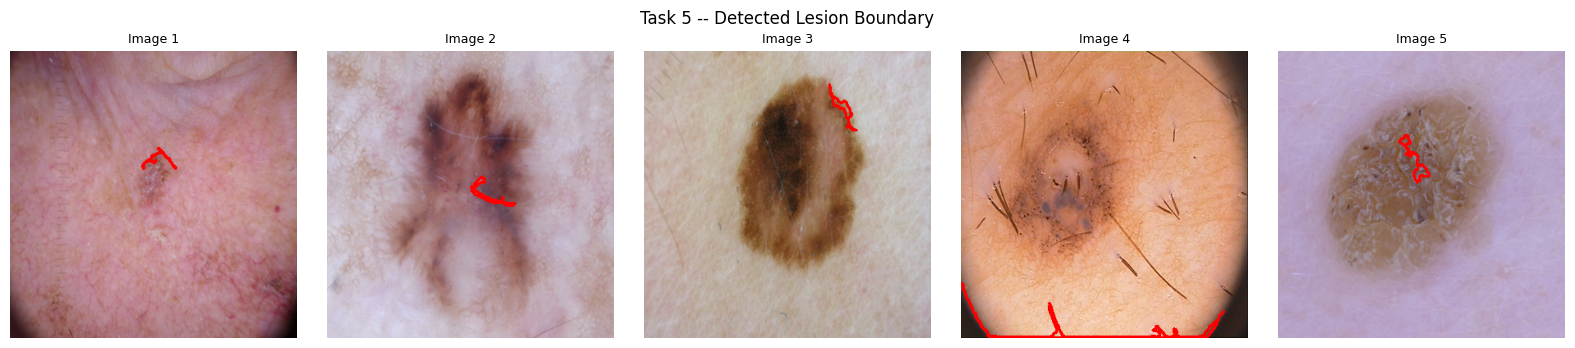

In [10]:
def detect_lesion_boundary(img_rgb, low, high, close_kernel=5):
    blurred = gaussian_filter(to_grayscale(img_rgb))
    edges = apply_canny(blurred, low, high)

    # Bridge small gaps so the boundary forms one connected contour.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel, close_kernel))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return edges, closed, None, img_rgb.copy()

    largest = max(contours, key=cv2.contourArea)

    boundary_img = img_rgb.copy()
    cv2.drawContours(boundary_img, [largest], -1, (255, 0, 0), 2)

    return edges, closed, largest, boundary_img


fig, axes = plt.subplots(1, len(sample_images), figsize=(3.2 * len(sample_images), 3.5))
boundary_results = {}
for ax, label, (cls, img) in zip(axes, IMAGE_LABELS, sample_images):
    edges, closed, contour, boundary_img = detect_lesion_boundary(img, BEST_LOW, BEST_HIGH)
    boundary_results[label] = (cls, img, edges, closed, contour, boundary_img)

    ax.imshow(boundary_img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.suptitle("Task 5 -- Detected Lesion Boundary")
plt.tight_layout()
plt.show()


## 8. Task 6 — Calculate Lesion Area and Perimeter

`cv2.contourArea` for area (pixels), `cv2.arcLength` (closed=True) for perimeter (pixels), computed from the largest contour found in Task 5.

In [11]:
area_perimeter_rows = []
for label, (cls, img, edges, closed, contour, boundary_img) in boundary_results.items():
    if contour is not None:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, closed=True)
    else:
        area, perimeter = float("nan"), float("nan")

    area_perimeter_rows.append({
        "Image": label,
        "Class": cls,
        "Best Filter": "Gaussian",
        "Edge Method": f"Canny ({BEST_LOW}-{BEST_HIGH})",
        "Area (pixels)": round(area, 1),
        "Perimeter (pixels)": round(perimeter, 1),
    })

results_table_df = pd.DataFrame(area_perimeter_rows)
display(results_table_df)


,Image,Class,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,actinic keratosis,Gaussian,Canny (50-100),47.0,157.8
1,Image 2,basal cell carcinoma,Gaussian,Canny (50-100),237.5,185.9
2,Image 3,melanoma,Gaussian,Canny (50-100),243.0,172.4
3,Image 4,nevus,Gaussian,Canny (50-100),683.5,919.3
4,Image 5,pigmented benign keratosis,Gaussian,Canny (50-100),345.5,200.4


## 9. Required Visualization

Original -> Grayscale -> Gaussian Filter -> Canny -> Lesion Boundary, for every image.

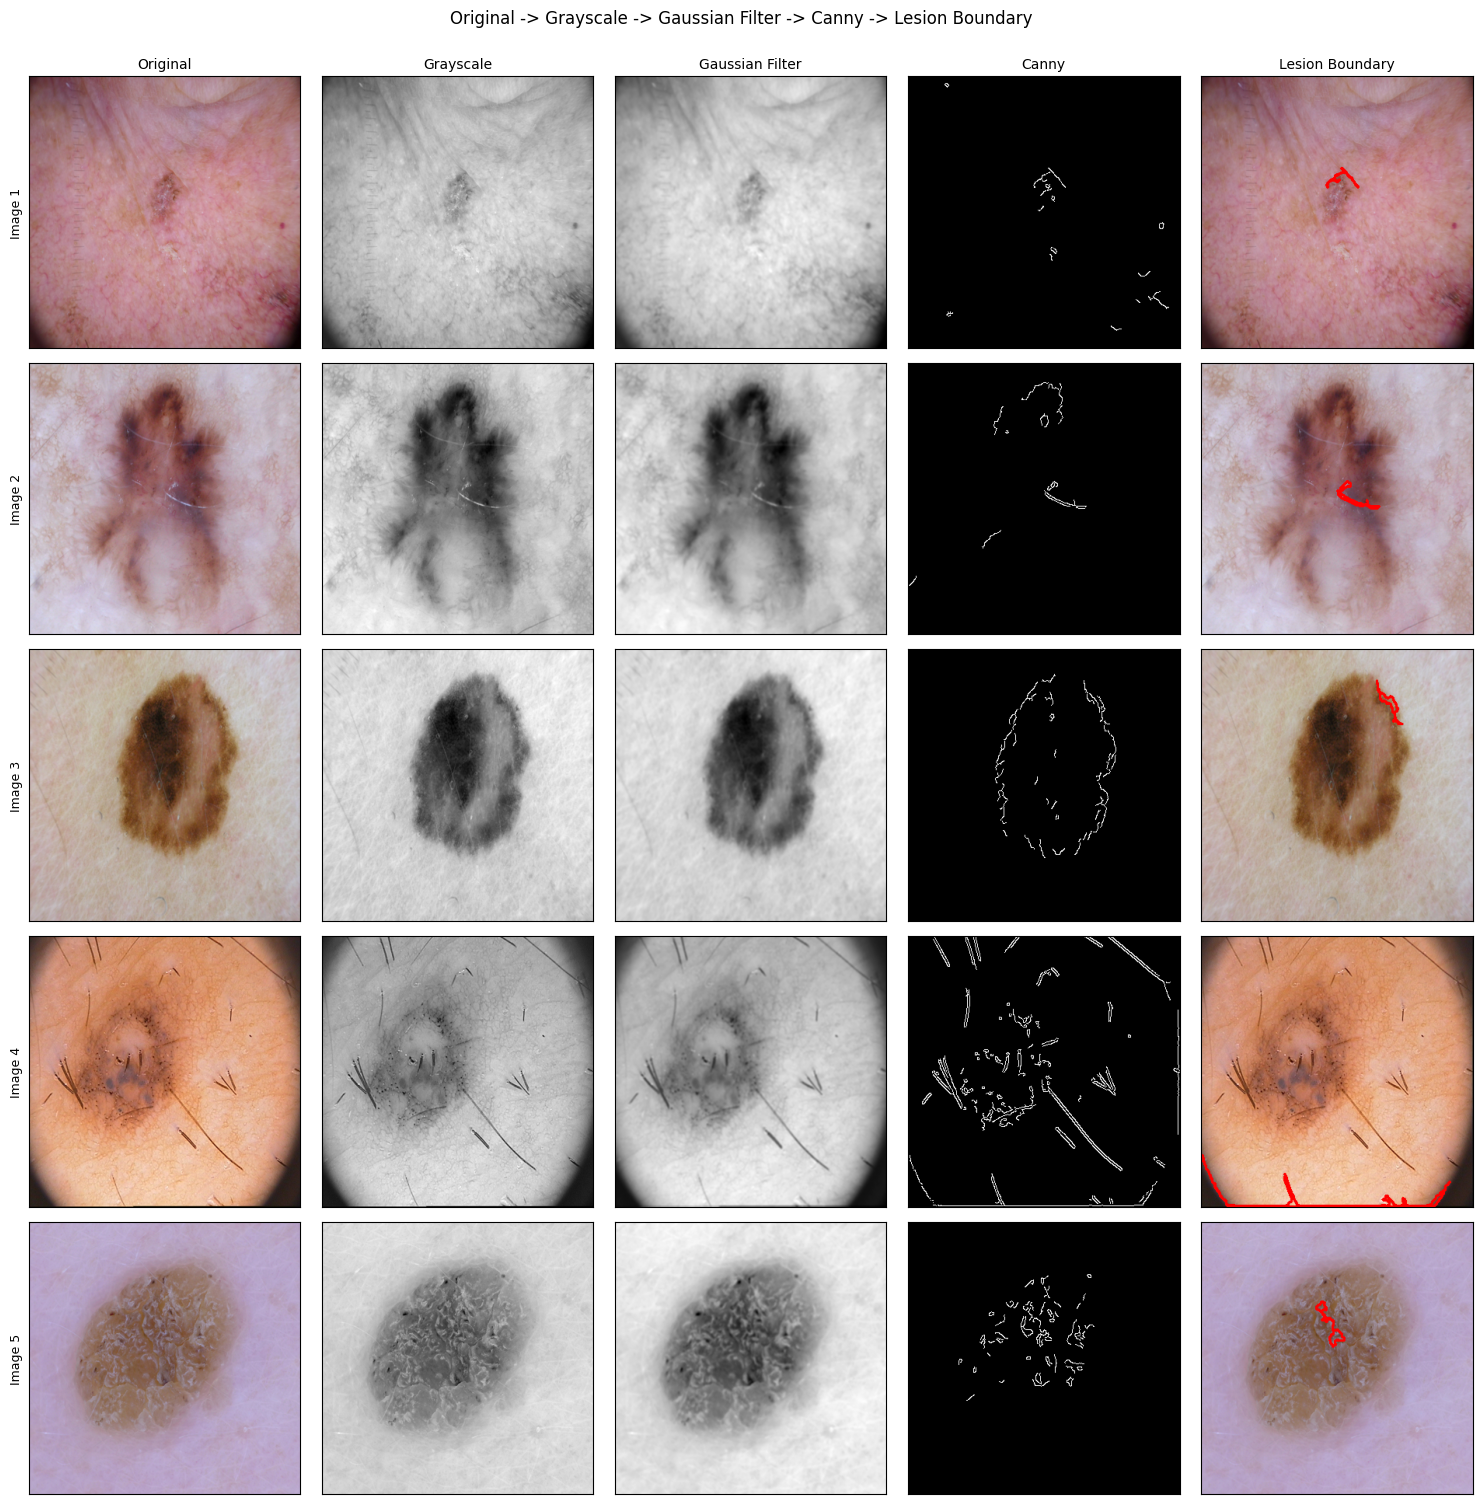

Saved required_visualization.png


In [12]:
n_stages = 5
fig, axes = plt.subplots(len(sample_images), n_stages,
                          figsize=(3.0 * n_stages, 3.0 * len(sample_images)))

for row, (label, (cls, img)) in enumerate(zip(IMAGE_LABELS, sample_images)):
    gray = to_grayscale(img)
    blurred = gaussian_filter(gray)
    edges = apply_canny(blurred, BEST_LOW, BEST_HIGH)
    _, _, _, boundary_img = detect_lesion_boundary(img, BEST_LOW, BEST_HIGH)

    stage_images = [img, gray, blurred, edges, boundary_img]
    stage_titles = ["Original", "Grayscale", "Gaussian Filter", "Canny", "Lesion Boundary"]
    cmaps = [None, "gray", "gray", "gray", None]

    for col, (im, title, cmap) in enumerate(zip(stage_images, stage_titles, cmaps)):
        ax = axes[row, col] if len(sample_images) > 1 else axes[col]
        ax.imshow(im, cmap=cmap)
        if row == 0:
            ax.set_title(title, fontsize=10)
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Original -> Grayscale -> Gaussian Filter -> Canny -> Lesion Boundary", y=1.0)
plt.tight_layout()
plt.savefig("required_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved required_visualization.png")


## 10. Final Comparison — Preprocessing Filter x Edge Method

8 combinations as required: **{Original, Average, Gaussian, Median} x {Sobel, Canny}**.
`Original` means no smoothing filter is applied before edge detection (grayscale only);
`Canny` uses the threshold pair selected in Task 4. Quantitative proxies (edge density,
contour-count fragmentation) are computed per combination, averaged across all 5 images, to
give an objective starting point for the qualitative columns the lab asks for (Noise
Handling / Edge Quality / Boundary Detection / Overall Performance) -- **these proxies inform
the write-up, they don't replace actually looking at the figure below.**

In [13]:
def average_filter(gray_img, kernel_size=5):
    return cv2.blur(gray_img, (kernel_size, kernel_size))


def median_filter(gray_img, kernel_size=5):
    return cv2.medianBlur(gray_img, kernel_size)


PREPROCESS_METHODS = {
    "Original": lambda g: g,
    "Average": average_filter,
    "Gaussian": gaussian_filter,
    "Median": median_filter,
}


def sobel_edges(gray_img):
    gx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
    # Threshold the gradient magnitude to a binary edge map for a fair comparison with Canny.
    _, mag_binary = cv2.threshold(mag, 50, 255, cv2.THRESH_BINARY)
    return mag_binary


EDGE_METHODS = {
    "Sobel": sobel_edges,
    "Canny": lambda g: apply_canny(g, BEST_LOW, BEST_HIGH),
}


In [14]:
comparison_rows = []
for prep_name, prep_fn in PREPROCESS_METHODS.items():
    for edge_name, edge_fn in EDGE_METHODS.items():
        densities, contour_counts = [], []
        for cls, img in sample_images:
            gray = to_grayscale(img)
            preprocessed = prep_fn(gray)
            edges = edge_fn(preprocessed)
            density = 100.0 * np.count_nonzero(edges) / edges.size
            contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
            densities.append(density)
            contour_counts.append(len(contours))

        comparison_rows.append({
            "Method": f"{prep_name} + {edge_name}",
            "Preprocessing": prep_name,
            "Edge Method": edge_name,
            "Avg Edge Density (%)": round(float(np.mean(densities)), 3),
            "Avg Contour Count": round(float(np.mean(contour_counts)), 1),
        })

comparison_metrics_df = pd.DataFrame(comparison_rows)
display(comparison_metrics_df)


,Method,Preprocessing,Edge Method,Avg Edge Density (%),Avg Contour Count
0,Original + Sobel,Original,Sobel,5.260,800.2
1,Original + Canny,Original,Canny,5.341,376.2
2,Average + Sobel,Average,Sobel,10.919,364.0
3,Average + Canny,Average,Canny,0.572,16.8
4,Gaussian + Sobel,Gaussian,Sobel,9.213,549.2
5,Gaussian + Canny,Gaussian,Canny,1.147,50.4
6,Median + Sobel,Median,Sobel,6.421,381.0
7,Median + Canny,Median,Canny,0.996,38.6


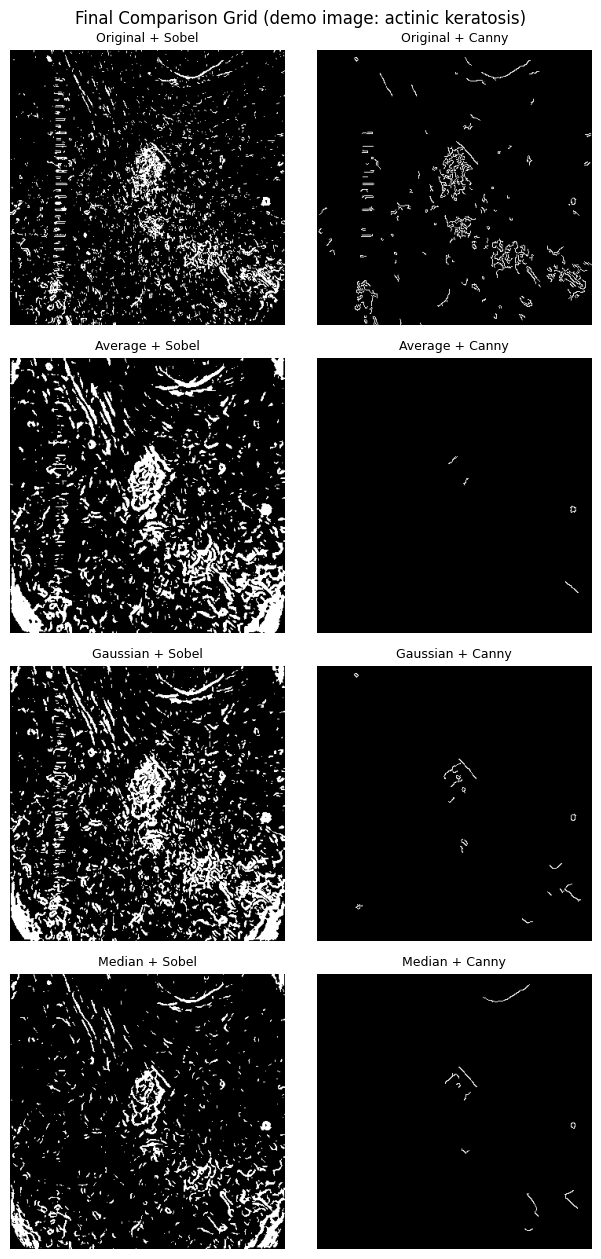

In [15]:
# Visual grid: every Preprocessing x Edge Method combination, for one representative image.
demo_cls, demo_img = sample_images[0]
demo_gray = to_grayscale(demo_img)

fig, axes = plt.subplots(len(PREPROCESS_METHODS), len(EDGE_METHODS),
                          figsize=(3.2 * len(EDGE_METHODS), 3.2 * len(PREPROCESS_METHODS)))
for row, (prep_name, prep_fn) in enumerate(PREPROCESS_METHODS.items()):
    preprocessed = prep_fn(demo_gray)
    for col, (edge_name, edge_fn) in enumerate(EDGE_METHODS.items()):
        edges = edge_fn(preprocessed)
        ax = axes[row, col]
        ax.imshow(edges, cmap="gray")
        ax.set_title(f"{prep_name} + {edge_name}", fontsize=9)
        ax.axis("off")

plt.suptitle(f"Final Comparison Grid (demo image: {demo_cls})")
plt.tight_layout()
plt.show()


In [16]:
def draft_qualitative(row, baseline_density, baseline_contours):
    # Lower density/contour-count relative to the Original+Sobel baseline suggests
    # better noise suppression; auto-drafted, confirm against the grid above.
    noise_handling = ("Good" if row["Avg Contour Count"] < baseline_contours * 0.7
                       else "Moderate" if row["Avg Contour Count"] < baseline_contours
                       else "Poor")
    edge_quality = ("Sparse/weak" if row["Avg Edge Density (%)"] < baseline_density * 0.3
                     else "Dense/noisy" if row["Avg Edge Density (%)"] > baseline_density * 1.1
                     else "Balanced")
    boundary_detection = ("Likely single clean contour" if row["Avg Contour Count"] < 15
                           else "Likely fragmented boundary")
    overall = "To confirm visually"
    return pd.Series([noise_handling, edge_quality, boundary_detection, overall])


baseline = comparison_metrics_df[comparison_metrics_df["Method"] == "Original + Sobel"].iloc[0]
final_comparison_df = comparison_metrics_df.copy()
final_comparison_df[["Noise Handling", "Edge Quality", "Boundary Detection",
                      "Overall Performance"]] = final_comparison_df.apply(
    lambda r: draft_qualitative(r, baseline["Avg Edge Density (%)"], baseline["Avg Contour Count"]),
    axis=1,
)
final_comparison_df = final_comparison_df[[
    "Method", "Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"
]]
display(final_comparison_df)


,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Poor,Balanced,Likely fragmented boundary,To confirm visually
1,Original + Canny,Good,Balanced,Likely fragmented boundary,To confirm visually
2,Average + Sobel,Good,Dense/noisy,Likely fragmented boundary,To confirm visually
3,Average + Canny,Good,Sparse/weak,Likely fragmented boundary,To confirm visually
4,Gaussian + Sobel,Good,Dense/noisy,Likely fragmented boundary,To confirm visually
5,Gaussian + Canny,Good,Sparse/weak,Likely fragmented boundary,To confirm visually
6,Median + Sobel,Good,Dense/noisy,Likely fragmented boundary,To confirm visually
7,Median + Canny,Good,Sparse/weak,Likely fragmented boundary,To confirm visually


## 11. Export results

In [17]:
os.makedirs("results", exist_ok=True)
results_table_df.to_csv("results/lab04_table_area_perimeter.csv", index=False)
threshold_df.to_csv("results/lab04_threshold_analysis.csv", index=False)
comparison_metrics_df.to_csv("results/lab04_comparison_metrics.csv", index=False)
final_comparison_df.to_csv("results/lab04_final_comparison.csv", index=False)
print("Saved all result CSVs to results/")


Saved all result CSVs to results/
